# Loan Default Prediction

## Import Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve, PrecisionRecallDisplay,
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [2]:
RANDOM_STATE = 42
TARGET = "Status"
DATA_PATH = os.path.join("Data", "Loan_Default.csv")

## Load and Clean Data

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df["Security_Type"] = df["Security_Type"].replace("Indriect", "Indirect")

In [5]:
df.shape

(148670, 34)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## Target Distribution

In [8]:
df[TARGET].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [9]:
(df[TARGET].value_counts(normalize=True) * 100).round(2)

Status
0    75.36
1    24.64
Name: proportion, dtype: float64

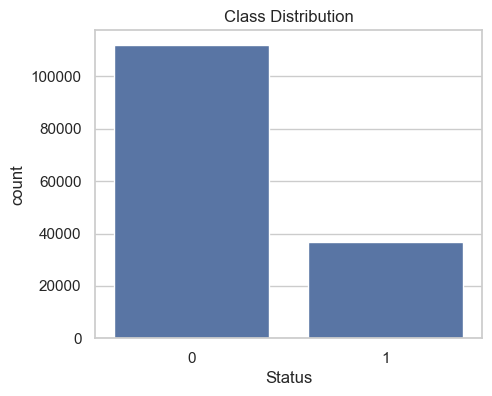

In [10]:
plt.figure(figsize=(5, 4))
sns.countplot(x=TARGET, data=df)
plt.title("Class Distribution")
plt.show()

## Full-Column Leakage Sanity Check

Before any columns are dropped, check **every** column in the raw file (not just the ones in the write-up) for a suspiciously large default-rate swing by category. A genuine risk factor shifts the default rate gradually; a leaked column tends to produce a near-deterministic split (close to 100% or close to 0% for one category), because it's encoding something other than pre-decision borrower risk. Flagged columns here should be added to the ablation study below before being trusted as model inputs.

In [11]:
base_rate = df[TARGET].mean()

In [12]:
round(base_rate, 4)

np.float64(0.2464)

In [13]:
cat_cols_full = df.drop(columns=["ID", "year", TARGET]).select_dtypes(exclude=np.number).columns.tolist()

In [14]:
cat_cols_full

['loan_limit',
 'Gender',
 'approv_in_adv',
 'loan_type',
 'loan_purpose',
 'Credit_Worthiness',
 'open_credit',
 'business_or_commercial',
 'Neg_ammortization',
 'interest_only',
 'lump_sum_payment',
 'construction_type',
 'occupancy_type',
 'Secured_by',
 'total_units',
 'credit_type',
 'co-applicant_credit_type',
 'age',
 'submission_of_application',
 'Region',
 'Security_Type']

In [15]:
sanity_rows = []
for col in cat_cols_full:
    grouped = df.groupby(col)[TARGET].agg(["mean", "size"])
    grouped = grouped[grouped["size"] >= 30]  # ignore tiny/noisy categories
    for level, row in grouped.iterrows():
        sanity_rows.append({
            "column": col,
            "category": str(level),
            "n": int(row["size"]),
            "default_rate": row["mean"],
            "lift_vs_base": row["mean"] / base_rate
        })

In [16]:
sanity_df = pd.DataFrame(sanity_rows).sort_values("lift_vs_base", ascending=False)

In [17]:
# anything close to a deterministic split on the target is suspicious
suspicious = sanity_df[(sanity_df["lift_vs_base"] > 3) | (sanity_df["lift_vs_base"] < 0.2)]

In [18]:
suspicious

,column,category,n,default_rate,lift_vs_base
33,Secured_by,land,33,1.000000,4.057698
57,Security_Type,Indirect,33,1.000000,4.057698
27,construction_type,mh,33,1.000000,4.057698
40,credit_type,EQUI,15298,0.999935,4.057433
25,lump_sum_payment,lpsm,3384,0.776596,3.151191


In [19]:
sanity_df.head(20)

,column,category,n,default_rate,lift_vs_base
33,Secured_by,land,33,1.000000,4.057698
57,Security_Type,Indirect,33,1.000000,4.057698
27,construction_type,mh,33,1.000000,4.057698
40,credit_type,EQUI,15298,0.999935,4.057433
25,lump_sum_payment,lpsm,3384,0.776596,3.151191
21,Neg_ammortization,neg_amm,15129,0.445965,1.809590
36,total_units,3U,393,0.384224,1.559065
9,loan_type,type2,20762,0.345439,1.401686
19,business_or_commercial,b/c,20762,0.345439,1.401686
35,total_units,2U,1477,0.345295,1.401101


## Remove Non-Predictive Columns

In [20]:
df_model = df.copy()

In [21]:
df_model = df_model.drop(columns=["ID", "year"])

In [22]:
df_model.shape[1] - 1  # feature count

31

## Train/Test Split — Before Preprocessing

In [23]:
train_df, test_df = train_test_split(
    df_model, test_size=0.20, random_state=RANDOM_STATE, stratify=df_model[TARGET]
)

In [24]:
X_train_raw = train_df.drop(columns=[TARGET]).copy()
y_train = train_df[TARGET].copy()

In [25]:
X_test_raw = test_df.drop(columns=[TARGET]).copy()
y_test = test_df[TARGET].copy()

In [26]:
print("Train:", X_train_raw.shape)
print("Test :", X_test_raw.shape)

Train: (118936, 31)
Test : (29734, 31)


In [27]:
print("Train default rate:", round(y_train.mean(), 4))
print("Test default rate :", round(y_test.mean(), 4))

Train default rate: 0.2464
Test default rate : 0.2465


## Missingness Count — Training Data Only

In [28]:
missing = X_train_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

In [29]:
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(X_train_raw) * 100).round(2)
})

In [30]:
missing_table

,missing_count,missing_pct
Upfront_charges,31720,26.67
Interest_rate_spread,29311,24.64
rate_of_interest,29155,24.51
dtir1,19254,16.19
property_value,12001,10.09
LTV,12001,10.09
income,7355,6.18
loan_limit,2696,2.27
approv_in_adv,715,0.60
age,156,0.13


## Missingness vs Default

In [31]:
rows = []
for col in X_train_raw.columns:
    missing_mask = X_train_raw[col].isna()

    if missing_mask.sum() == 0 or missing_mask.sum() == len(X_train_raw):
        continue

    rows.append({
        "column": col,
        "missing_pct": round(missing_mask.mean() * 100, 2),
        "default_rate_missing": round(y_train[missing_mask].mean(), 3),
        "default_rate_present": round(y_train[~missing_mask].mean(), 3)
    })

In [32]:
missing_vs_default = pd.DataFrame(rows)

In [33]:
missing_vs_default["difference"] = (
    missing_vs_default["default_rate_missing"] - missing_vs_default["default_rate_present"]
).abs()

In [34]:
missing_vs_default.sort_values("difference", ascending=False)

,column,missing_pct,default_rate_missing,default_rate_present,difference
4,Interest_rate_spread,24.64,1.000,0.000,1.000
3,rate_of_interest,24.51,1.000,0.002,0.998
5,Upfront_charges,26.67,0.920,0.001,0.919
8,property_value,10.09,1.000,0.162,0.838
12,LTV,10.09,1.000,0.162,0.838
10,age,0.13,1.000,0.245,0.755
11,submission_of_application,0.13,1.000,0.245,0.755
13,dtir1,16.19,0.674,0.164,0.510
6,term,0.03,0.394,0.246,0.148
9,income,6.18,0.137,0.254,0.117


## Ablation Study — Candidate Leakage Columns

In [35]:
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [36]:
candidate_cols = [
    "rate_of_interest", "Interest_rate_spread", "Upfront_charges", "property_value",
    "credit_type", "co-applicant_credit_type", "Secured_by", "Security_Type",
    "age", "submission_of_application", "LTV", "dtir1"
]

In [37]:
cv_ablation = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [38]:
def cv_score(X, y):
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), cat_cols)
    ])

    model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                           eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)

    pipe = Pipeline([("preprocess", pre), ("model", model)])
    scores = cross_validate(pipe, X, y, cv=cv_ablation,
                             scoring=["roc_auc", "average_precision"], n_jobs=-1)
    return scores["test_roc_auc"].mean(), scores["test_average_precision"].mean()

In [39]:
dropped = []
ablation_rows = []

In [40]:
roc, pr = cv_score(X_train_raw, y_train)
ablation_rows.append({"n_cols_dropped": 0, "last_column_dropped": "(none)",
                       "CV ROC-AUC": roc, "CV PR-AUC": pr})

In [41]:
for col in candidate_cols:
    dropped.append(col)
    roc, pr = cv_score(X_train_raw.drop(columns=dropped), y_train)
    ablation_rows.append({"n_cols_dropped": len(dropped), "last_column_dropped": col,
                           "CV ROC-AUC": roc, "CV PR-AUC": pr})

In [42]:
ablation_df = pd.DataFrame(ablation_rows)

In [43]:
ablation_df.round(4)

,n_cols_dropped,last_column_dropped,CV ROC-AUC,CV PR-AUC
0,0,(none),1.0000,1.0000
1,1,rate_of_interest,1.0000,0.9999
2,2,Interest_rate_spread,0.9970,0.9898
3,3,Upfront_charges,0.8929,0.8373
4,4,property_value,0.8929,0.8374
5,5,credit_type,0.8928,0.8367
6,6,co-applicant_credit_type,0.8923,0.8362
7,7,Secured_by,0.8923,0.8362
8,8,Security_Type,0.8923,0.8362
9,9,age,0.8924,0.8360


## Ablation Study Plot

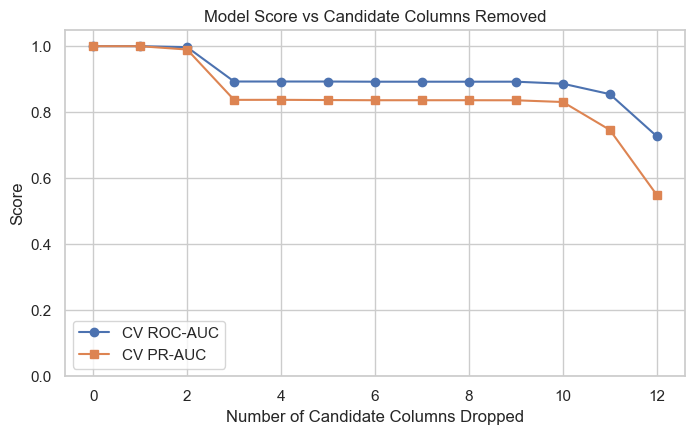

In [44]:
plt.figure(figsize=(8, 4.5))
plt.plot(ablation_df["n_cols_dropped"], ablation_df["CV ROC-AUC"], marker="o", label="CV ROC-AUC")
plt.plot(ablation_df["n_cols_dropped"], ablation_df["CV PR-AUC"], marker="s", label="CV PR-AUC")
plt.xlabel("Number of Candidate Columns Dropped")
plt.ylabel("Score")
plt.title("Model Score vs Candidate Columns Removed")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

## Leakage Correction

Two pieces of evidence feed this decision: the full-column sanity check above and
the ablation curve.

Dropped for leakage:

- `rate_of_interest`
- `Interest_rate_spread`
- `Upfront_charges`
- `property_value`
- `credit_type`

In [45]:
leakage_cols = [
    "rate_of_interest", "Interest_rate_spread", "Upfront_charges",
    "property_value", "credit_type"       # flagged by the sanity check: EQUI defaults at 99.99%
]

In [46]:
X_train = X_train_raw.drop(columns=leakage_cols)
X_test = X_test_raw.drop(columns=leakage_cols)

In [47]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

In [48]:
X_train.shape[1]  # final feature count

26

## Remaining Missing Values

In [49]:
remaining_missing = X_train.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

In [50]:
pd.DataFrame({
    "missing_count": remaining_missing,
    "missing_pct": (remaining_missing / len(X_train) * 100).round(2)
})

,missing_count,missing_pct
dtir1,19254,16.19
LTV,12001,10.09
income,7355,6.18
loan_limit,2696,2.27
approv_in_adv,715,0.60
age,156,0.13
submission_of_application,156,0.13
loan_purpose,103,0.09
Neg_ammortization,96,0.08
term,33,0.03


- add **`loan_to_income`** — loan amount relative to income, since a given loan size means something
  different for a low vs. high earner. This is a genuine interaction the model can't easily
  reconstruct on its own.

In [51]:
X_train["loan_to_income"] = X_train["loan_amount"] / X_train["income"]
X_train.loc[X_train["income"] <= 0, "loan_to_income"] = np.nan

In [52]:
X_test["loan_to_income"] = X_test["loan_amount"] / X_test["income"]
X_test.loc[X_test["income"] <= 0, "loan_to_income"] = np.nan

In [53]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

In [54]:
X_train[["loan_to_income"]].head()

,loan_to_income
141039,32.468553
121276,91.470588
11214,118.297101
129659,20.853659
13370,79.285714


## Univariate Analysis — Numeric Feature Distributions

In [55]:
numeric_plot_cols = [c for c in numeric_features if c != "term"][:9]

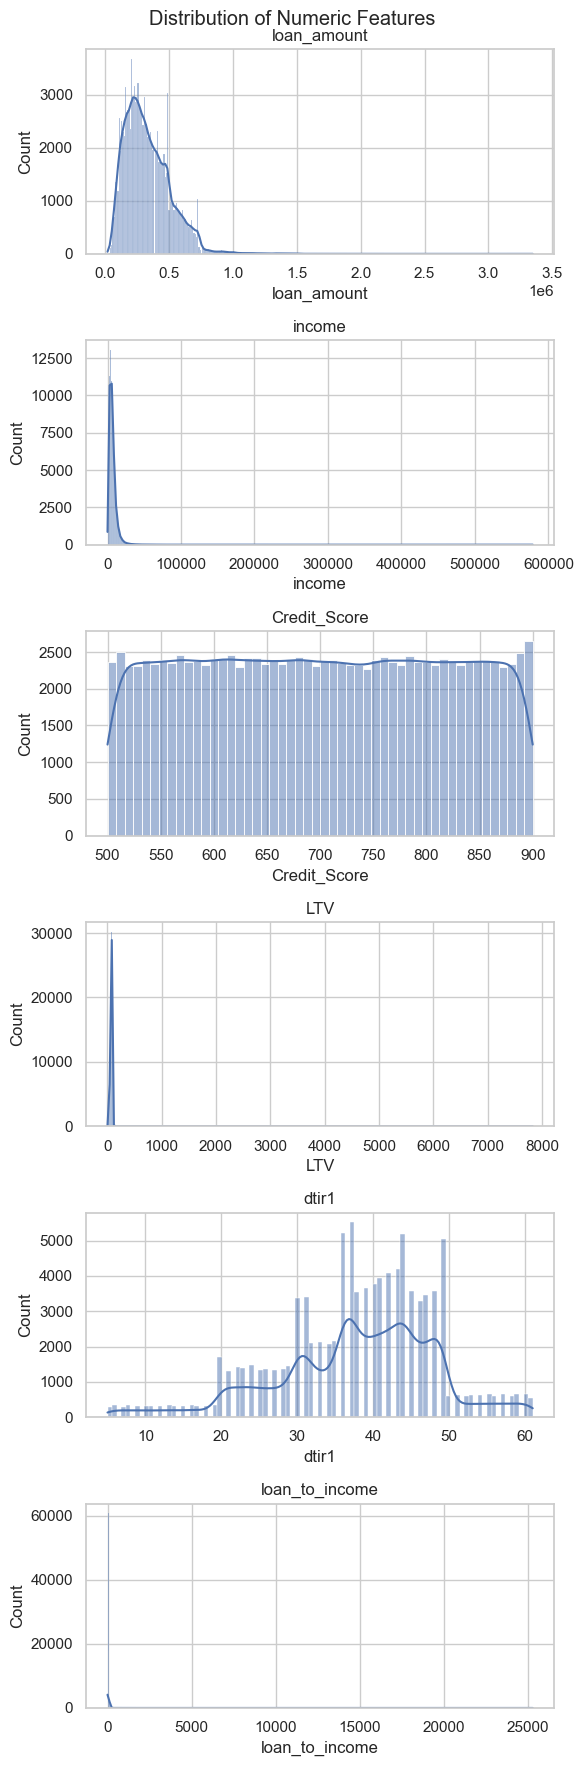

In [56]:
n = len(numeric_plot_cols)
fig, axes = plt.subplots(n, 1, figsize=(6, 3 * n))
axes = np.array(axes).flatten()

for i, col in enumerate(numeric_plot_cols):
    sns.histplot(X_train[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

## Bivariate Analysis — Numeric Features vs Target

In [57]:
box_df = X_train[numeric_plot_cols].copy()
box_df[TARGET] = y_train.values

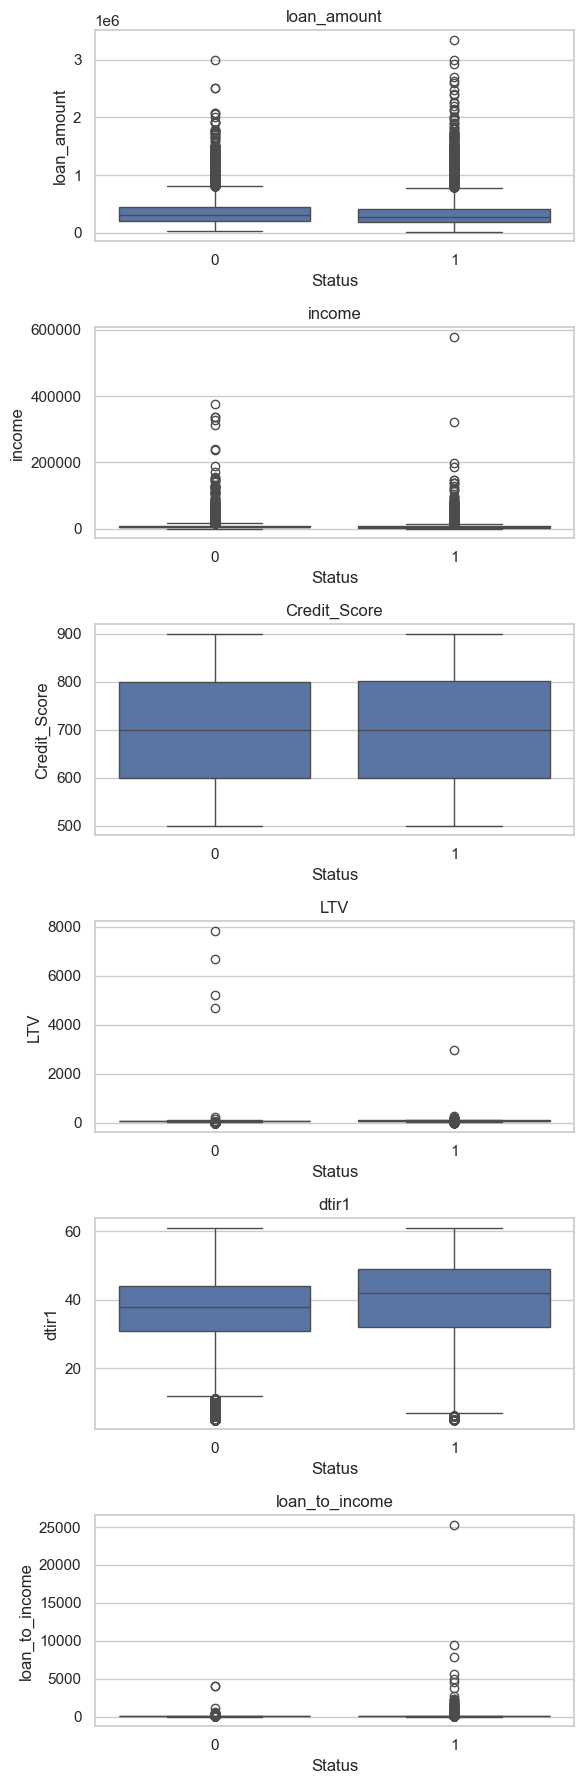

In [58]:
n = len(numeric_plot_cols)
fig, axes = plt.subplots(n, 1, figsize=(6, 3 * n))
axes = np.array(axes).flatten()

for i, col in enumerate(numeric_plot_cols):
    sns.boxplot(x=TARGET, y=col, data=box_df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Status")

plt.tight_layout()
plt.show()

## Bivariate Analysis — Categorical Features vs Target

In [59]:
cols = categorical_features[:6]

In [60]:
cat_df = X_train.copy()
cat_df[TARGET] = y_train.values

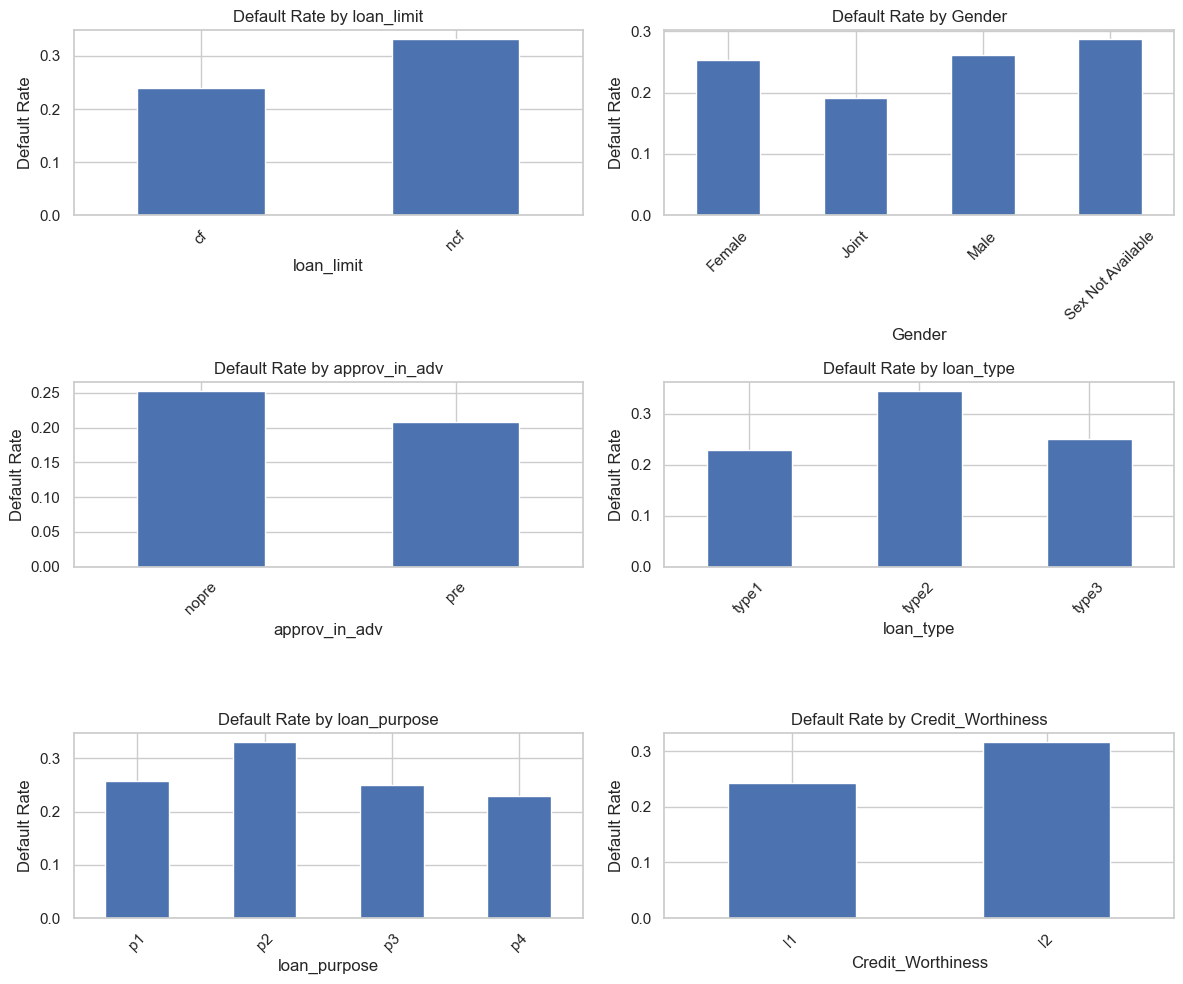

In [61]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    rate = cat_df.groupby(col)[TARGET].mean()
    rate.plot(kind="bar", ax=axes[i])
    axes[i].set_title("Default Rate by " + col)
    axes[i].set_ylabel("Default Rate")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [62]:
corr_df = X_train[numeric_features].copy()
corr_df[TARGET] = y_train.values

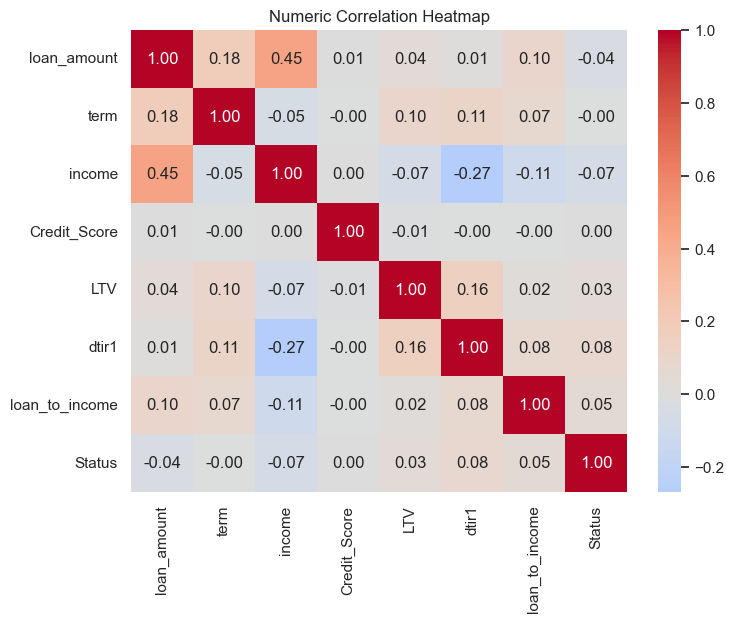

In [63]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Correlation Heatmap")
plt.show()

In [64]:
term_df = X_train.copy()
term_df["Status"] = y_train.values
term_default_rate = term_df.groupby("term")["Status"].mean().sort_index()

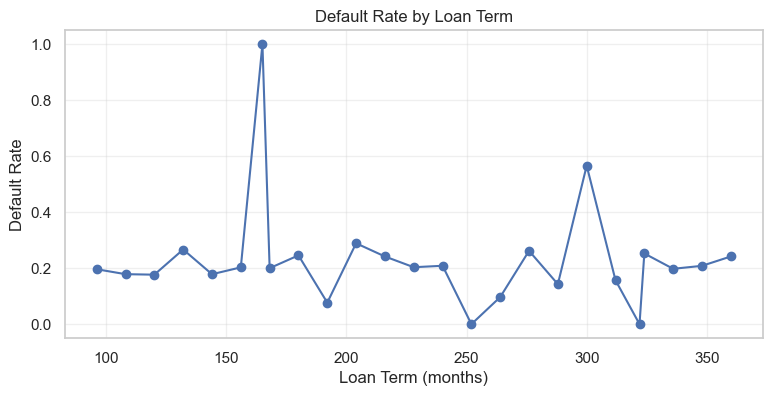

In [65]:
plt.figure(figsize=(9, 4))
plt.plot(term_default_rate.index, term_default_rate.values, marker="o")
plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term (months)")
plt.ylabel("Default Rate")
plt.grid(alpha=0.3)
plt.show()

## Preprocessing and Model Builders

In [66]:
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [67]:
n_num = len(numeric_features)
n_cat = len(categorical_features)
cat_idx = list(range(n_num, n_num + n_cat))  # positions SMOTENC needs, after imputing

In [68]:
imputer = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", SimpleImputer(strategy="most_frequent"), categorical_features),
])

In [69]:
# one-hot encoding happens after SMOTENC so SMOTENC still sees plain categories
encoder = ColumnTransformer([
    ("num", FunctionTransformer(np.asarray, kw_args={"dtype": float}), list(range(n_num))),
    ("cat", onehot, cat_idx),
])

In [70]:
models = ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]

In [71]:
strategies = ["Class weighting", "SMOTENC"]  # two imbalance strategies, compared separately

## Model and Imbalance Strategy Selection

In [72]:
def build_model(name, weighted):
    if name == "Logistic Regression":
        return LogisticRegression(max_iter=1000, class_weight="balanced" if weighted else None)
    if name == "Random Forest":
        return RandomForestClassifier(n_estimators=200, class_weight="balanced" if weighted else None,
                                       random_state=RANDOM_STATE, n_jobs=-1)
    if name == "XGBoost":
        return XGBClassifier(n_estimators=250, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=dev_pos_weight if weighted else 1.0,
                              eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
    if name == "LightGBM":
        return LGBMClassifier(n_estimators=250, max_depth=6, learning_rate=0.05,
                               class_weight="balanced" if weighted else None,
                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

In [73]:
def build_pipeline(model, use_smote):
    steps = [("impute", imputer)]
    if use_smote:
        steps.append(("smote", SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE, k_neighbors=5)))
    steps.append(("encode", encoder))
    steps.append(("model", model))
    return ImbPipeline(steps) if use_smote else Pipeline(steps)

In [74]:
# split training data into development (model selection) and validation (threshold selection)
X_dev, X_val, y_dev, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train
)

In [75]:
dev_pos_weight = (y_dev == 0).sum() / (y_dev == 1).sum()

In [76]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [77]:
results = []
for model_name in models:
    for strategy in strategies:
        print("Running:", model_name, "|", strategy)
        weighted = strategy == "Class weighting"
        use_smote = strategy == "SMOTENC"

        pipe = build_pipeline(build_model(model_name, weighted), use_smote)
        scores = cross_validate(pipe, X_dev, y_dev, cv=cv,
                                 scoring=["roc_auc", "average_precision"], n_jobs=-1)

        results.append({
            "Model": model_name,
            "Strategy": strategy,
            "CV ROC-AUC": scores["test_roc_auc"].mean(),
            "CV PR-AUC": scores["test_average_precision"].mean()
        })

Running: Logistic Regression | Class weighting
Running: Logistic Regression | SMOTENC
Running: Random Forest | Class weighting
Running: Random Forest | SMOTENC
Running: XGBoost | Class weighting
Running: XGBoost | SMOTENC
Running: LightGBM | Class weighting
Running: LightGBM | SMOTENC


In [78]:
cv_results = pd.DataFrame(results).sort_values(
    ["CV PR-AUC", "CV ROC-AUC"], ascending=False
).reset_index(drop=True)

In [79]:
cv_results.round(4)

,Model,Strategy,CV ROC-AUC,CV PR-AUC
0,XGBoost,Class weighting,0.8945,0.8393
1,LightGBM,Class weighting,0.8948,0.8390
2,Random Forest,Class weighting,0.8843,0.8229
3,LightGBM,SMOTENC,0.8688,0.8107
4,XGBoost,SMOTENC,0.8661,0.8064
5,Random Forest,SMOTENC,0.8582,0.7752
6,Logistic Regression,Class weighting,0.7177,0.4615
7,Logistic Regression,SMOTENC,0.6801,0.4170


In [80]:
best_model_name = cv_results.loc[0, "Model"]
best_strategy = cv_results.loc[0, "Strategy"]

In [81]:
print("Best model:", best_model_name)
print("Best strategy:", best_strategy)

Best model: XGBoost
Best strategy: Class weighting


In [82]:
weighted = best_strategy == "Class weighting"
use_smote = best_strategy == "SMOTENC"

In [83]:
tuned_pipe = build_pipeline(build_model(best_model_name, weighted), use_smote)

In [84]:
# hyperparameter grids are model-specific
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    },
    "Random Forest": {
        "model__n_estimators": [150, 250, 350, 500],
        "model__max_depth": [4, 6, 8, None],
        "model__min_samples_leaf": [1, 5, 10, 20],
    },
    "XGBoost": {
        "model__n_estimators": [150, 250, 350, 500],
        "model__max_depth": [4, 6, 8, 10],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__min_child_weight": [1, 5, 10],
    },
    "LightGBM": {
        "model__n_estimators": [150, 250, 350, 500],
        "model__max_depth": [4, 6, 8, -1],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63],
        "model__min_child_samples": [10, 20, 40],
    },
}

In [85]:
search = RandomizedSearchCV(
    tuned_pipe,
    param_distributions=param_grids[best_model_name],
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [86]:
search.fit(X_dev, y_dev)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 6, ...], 'model__min_child_weight': [1, 5, ...], 'model__n_estimators': [150, 250, ...]}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [87]:
search.best_params_

{'model__n_estimators': 350,
 'model__min_child_weight': 5,
 'model__max_depth': 6,
 'model__learning_rate': 0.05}

In [88]:
round(search.best_score_, 4)

np.float64(0.84)

## Threshold Tuning

In [89]:
# search already refit the best pipeline on X_dev/y_dev, so we can use it directly
val_prob = search.best_estimator_.predict_proba(X_val)[:, 1]

In [90]:
precision, recall, thresholds = precision_recall_curve(y_val, val_prob)

In [91]:
f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)

In [92]:
best_index = np.argmax(f1_values)
best_threshold = float(thresholds[best_index])

In [93]:
print("Best threshold:", round(best_threshold, 3))
print("Validation precision:", round(precision[best_index], 3))
print("Validation recall:", round(recall[best_index], 3))
print("Validation F1:", round(f1_values[best_index], 3))

Best threshold: 0.643
Validation precision: 0.885
Validation recall: 0.65
Validation F1: 0.749


## Precision, Recall and F1 vs Threshold

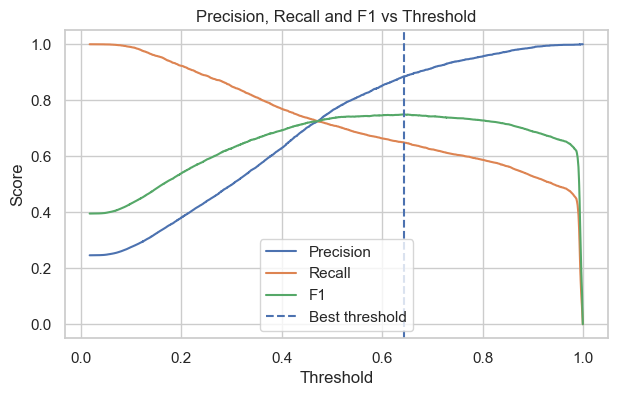

In [94]:
plt.figure(figsize=(7, 4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_values, label="F1")
plt.axvline(best_threshold, linestyle="--", label="Best threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")
plt.legend()
plt.show()

## Final Test Evaluation

In [95]:
# refit the selected pipeline on the full training set; test set used only here
best_pipe = search.best_estimator_

In [96]:
full_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [97]:
if best_model_name == "XGBoost" and best_strategy == "Class weighting":
    best_pipe.set_params(model__scale_pos_weight=full_pos_weight)

In [98]:
best_pipe.fit(X_train, y_train)

,steps,"[('impute', ...), ('encode', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [99]:
test_prob = best_pipe.predict_proba(X_test)[:, 1]

In [100]:
test_pred = (test_prob >= best_threshold).astype(int)

In [101]:
metrics = {
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "Accuracy": (test_pred == y_test).mean()
}

In [102]:
print(classification_report(y_test, test_pred, digits=3, zero_division=0))

              precision    recall  f1-score   support

           0      0.901     0.973     0.936     22406
           1      0.890     0.674     0.767      7328

    accuracy                          0.899     29734
   macro avg      0.895     0.823     0.851     29734
weighted avg      0.898     0.899     0.894     29734



In [103]:
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

ROC-AUC: 0.8993
PR-AUC: 0.8501
Precision: 0.8896
Recall: 0.6739
F1: 0.7668
Accuracy: 0.8990


## Confusion Matrix and Precision-Recall Curve

In [104]:
cm = confusion_matrix(y_test, test_pred)

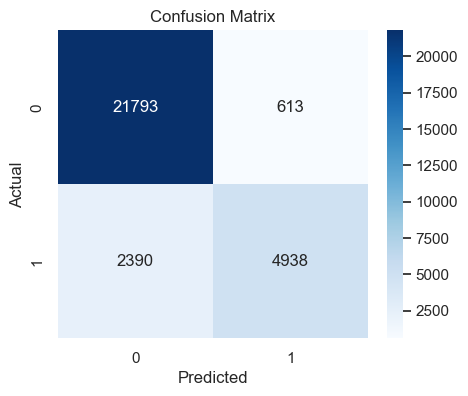

In [105]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

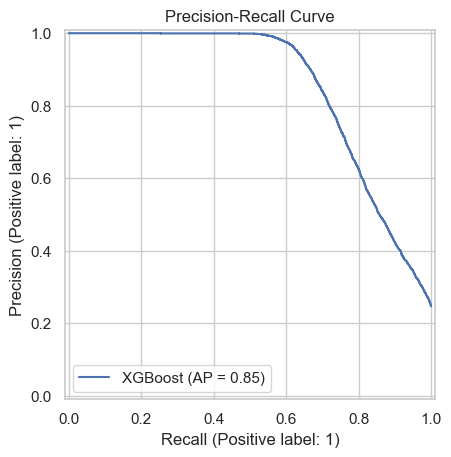

In [106]:
PrecisionRecallDisplay.from_predictions(y_test, test_prob, name=best_model_name)
plt.title("Precision-Recall Curve")
plt.show()

## ROC Curve

In [107]:
fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = roc_auc_score(y_test, test_prob)

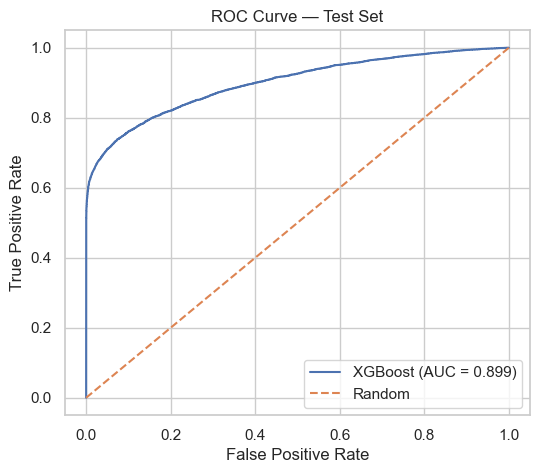

In [108]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.show()

## Calibration Curve

In [109]:
prob_true, prob_pred = calibration_curve(y_test, test_prob, n_bins=10)

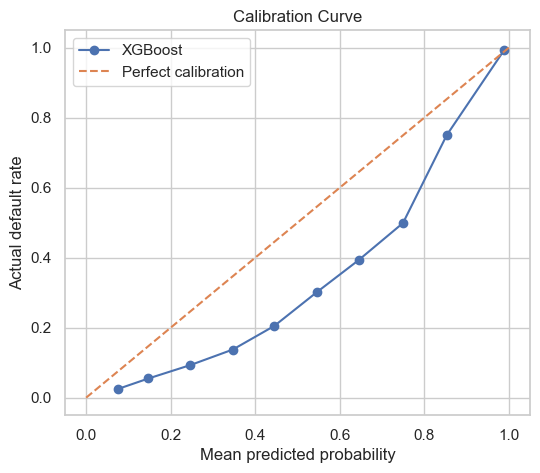

In [110]:
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label=best_model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual default rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

## Feature Importance

In [111]:
imputer_fitted = best_pipe.named_steps["impute"]
encoder_fitted = best_pipe.named_steps["encode"]
model = best_pipe.named_steps["model"]

In [112]:
X_test_imputed = imputer_fitted.transform(X_test)
X_test_transformed = encoder_fitted.transform(X_test_imputed)

In [113]:
cat_names = encoder_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_names])

In [114]:
if hasattr(model, "feature_importances_"):
    importance = model.feature_importances_
else:
    importance = np.abs(model.coef_[0])

In [115]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

In [116]:
importance_df.head(20)

,feature,importance
32,lump_sum_payment_lpsm,0.129141
4,LTV,0.123979
28,Neg_ammortization_neg_amm,0.083457
54,submission_of_application_not_inst,0.065703
15,loan_type_type1,0.049130
22,Credit_Worthiness_l1,0.046665
5,dtir1,0.044064
17,loan_type_type3,0.032118
16,loan_type_type2,0.030138
13,approv_in_adv_nopre,0.027522


In [117]:
top_features = importance_df.head(20).sort_values("importance")

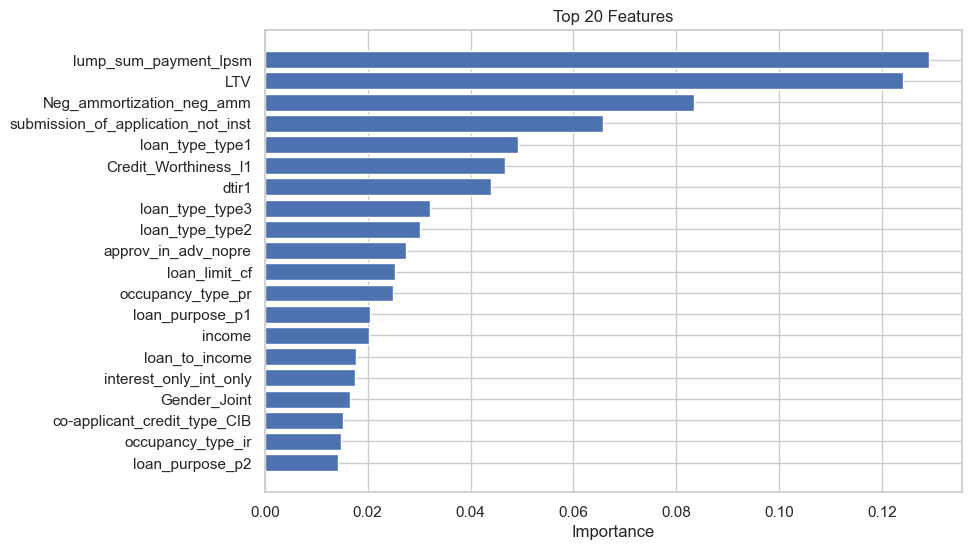

In [118]:
plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top 20 Features")
plt.show()

## SHAP Explainability

In [119]:
n_shap = min(300, len(X_test_transformed))
rng = np.random.RandomState(RANDOM_STATE)
indices = rng.choice(len(X_test_transformed), n_shap, replace=False)
X_shap = X_test_transformed[indices]

In [120]:
if hasattr(model, "feature_importances_"):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background_raw = X_train.sample(min(300, len(X_train)), random_state=RANDOM_STATE)
    background = encoder_fitted.transform(imputer_fitted.transform(background_raw))
    explainer = shap.LinearExplainer(model, background)
    shap_values = explainer.shap_values(X_shap)

In [121]:
np.asarray(shap_values).shape

(300, 62)

## Global SHAP Importance

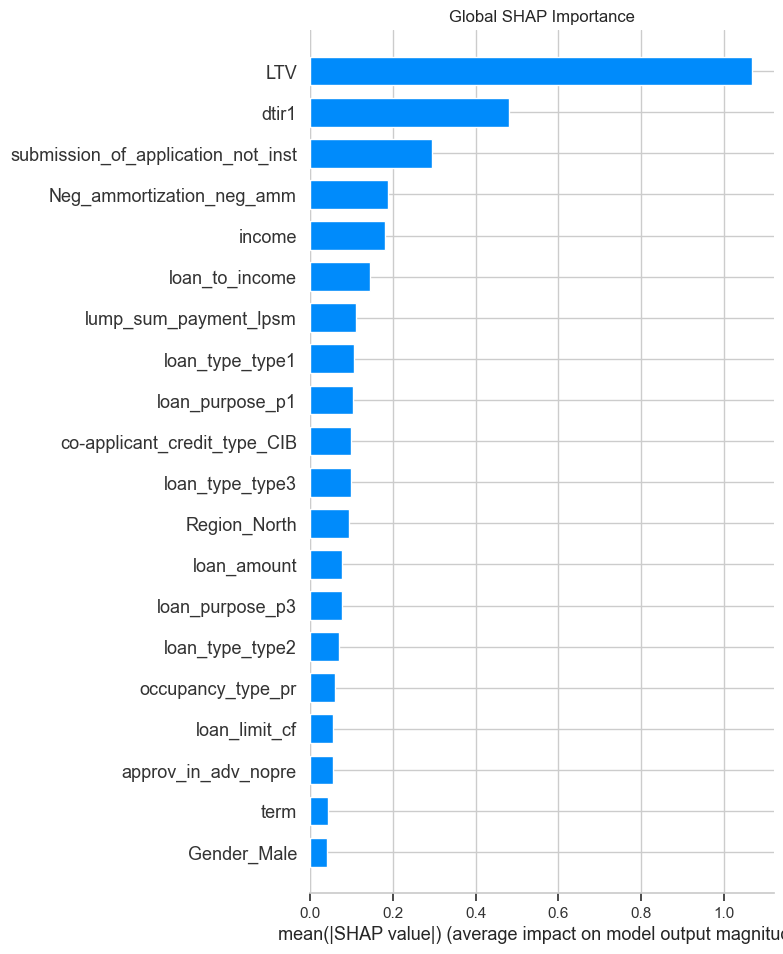

In [122]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Global SHAP Importance")
plt.show()

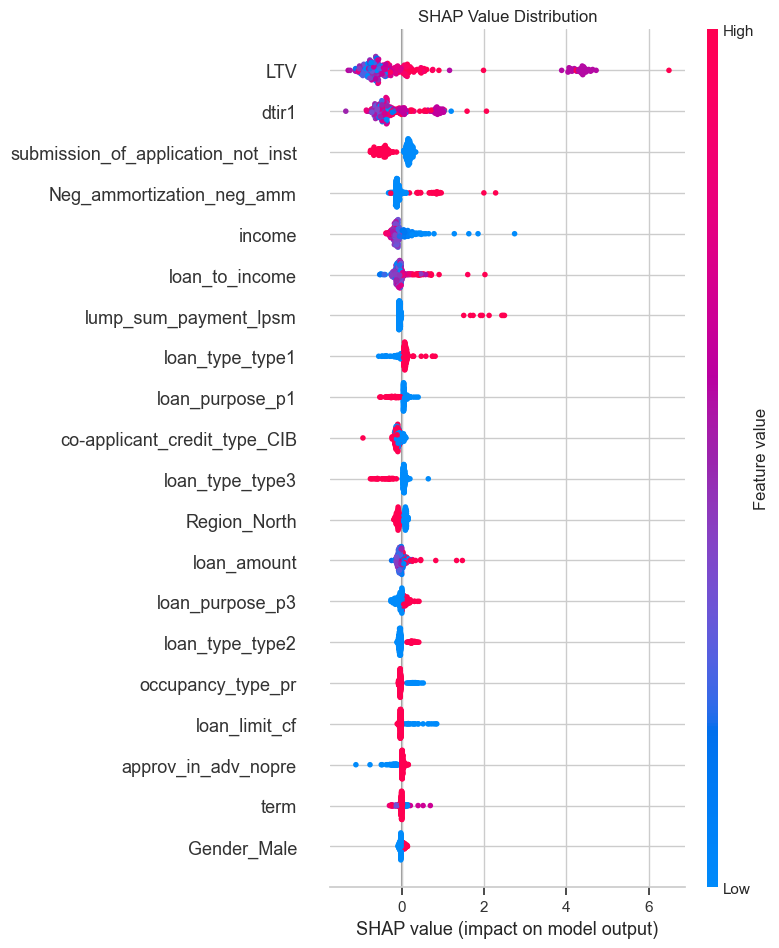

In [123]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.title("SHAP Value Distribution")
plt.show()

## SHAP Dependence Plots

In [124]:
top3 = importance_df.head(3)["feature"].tolist()

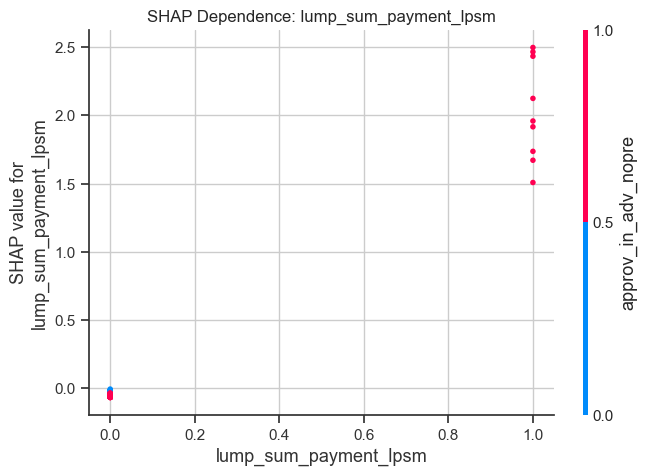

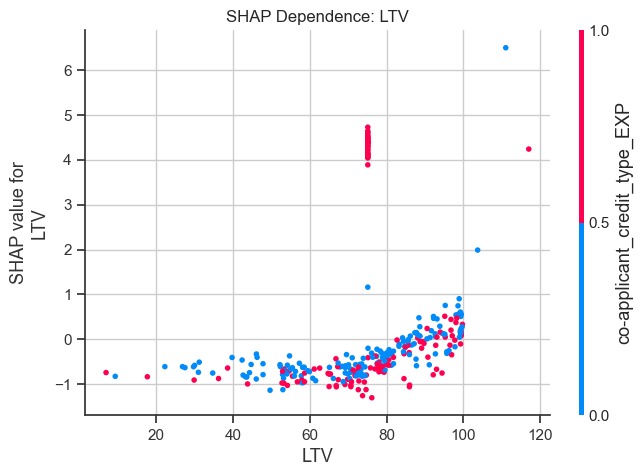

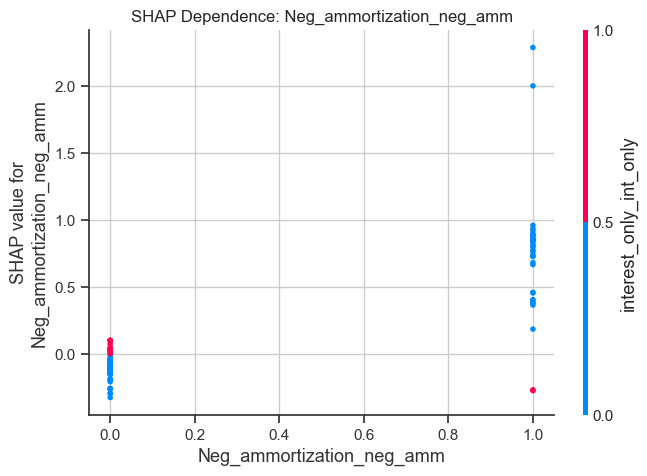

In [125]:
for feature in top3:
    index = list(feature_names).index(feature)
    shap.dependence_plot(index, shap_values, X_shap, feature_names=feature_names, show=False)
    plt.title(f"SHAP Dependence: {feature}")
    plt.show()

## SHAP Waterfall — Highest and Lowest Risk

In [126]:
expected_value = explainer.expected_value
if isinstance(expected_value, np.ndarray):
    expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]

In [127]:
high_idx = np.argmax(test_prob)
low_idx = np.argmin(test_prob)

In [128]:
X_test_one = encoder_fitted.transform(imputer_fitted.transform(X_test.iloc[[high_idx]]))
X_test_low = encoder_fitted.transform(imputer_fitted.transform(X_test.iloc[[low_idx]]))

In [129]:
high_values = explainer.shap_values(X_test_one)
low_values = explainer.shap_values(X_test_low)

In [130]:
if isinstance(high_values, list):
    high_values = high_values[1]
if isinstance(low_values, list):
    low_values = low_values[1]

In [131]:
high_exp = shap.Explanation(values=high_values[0], base_values=expected_value,
                             data=X_test_one[0], feature_names=feature_names)

In [132]:
low_exp = shap.Explanation(values=low_values[0], base_values=expected_value,
                            data=X_test_low[0], feature_names=feature_names)

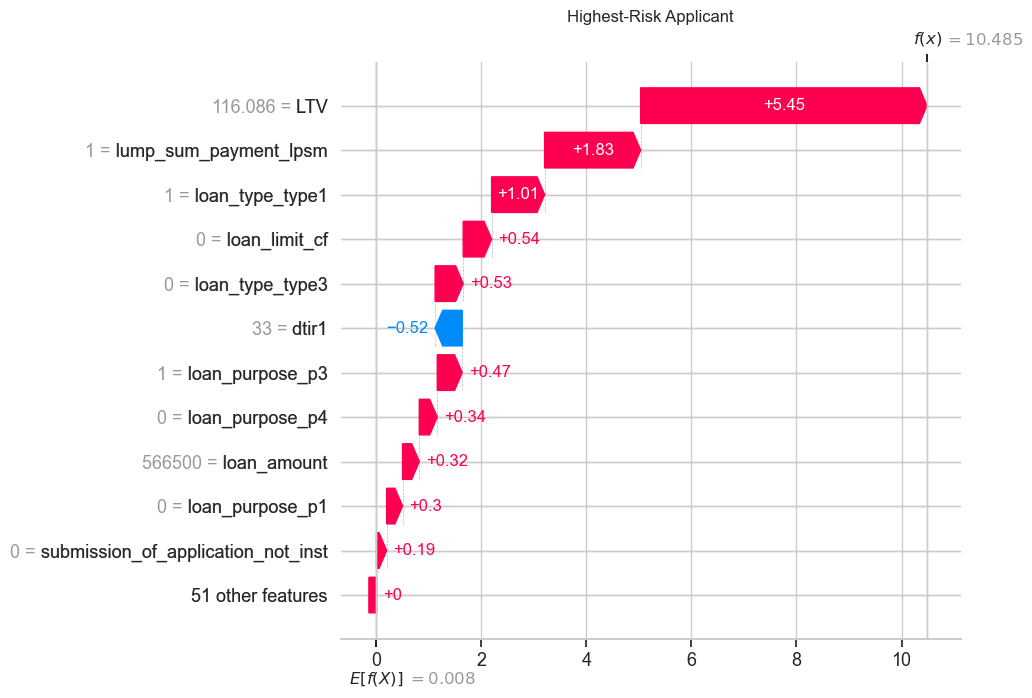

In [133]:
shap.plots.waterfall(high_exp, max_display=12, show=False)
plt.title("Highest-Risk Applicant")
plt.show()

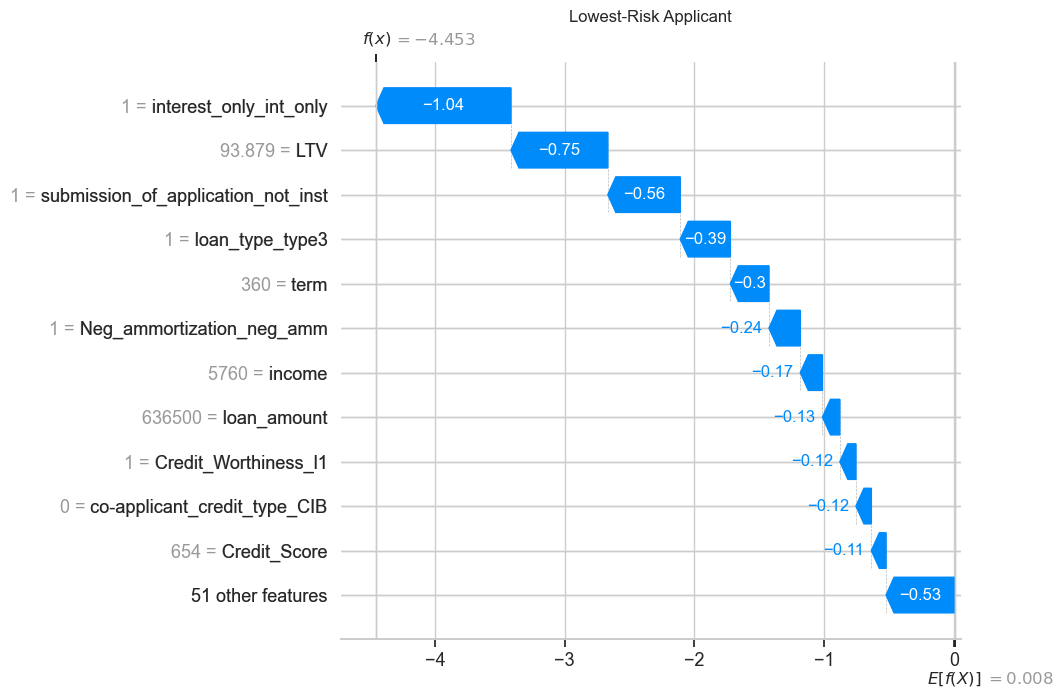

In [134]:
shap.plots.waterfall(low_exp, max_display=12, show=False)
plt.title("Lowest-Risk Applicant")
plt.show()

## Risk Bands

In [135]:
risk_df = X_test.copy()
risk_df["actual_default"] = y_test.values
risk_df["predicted_probability"] = test_prob

In [136]:
bands = []
for p in risk_df["predicted_probability"]:
    if p >= 0.66:
        bands.append("High risk")
    elif p >= 0.33:
        bands.append("Medium risk")
    else:
        bands.append("Low risk")

In [137]:
risk_df["risk_band"] = bands

In [138]:
band_order = ["Low risk", "Medium risk", "High risk"]

In [139]:
band_summary = risk_df.groupby("risk_band")["actual_default"].agg(["size", "mean"])
band_summary.columns = ["applicants", "actual_default_rate"]

In [140]:
band_summary["avg_predicted_probability"] = risk_df.groupby("risk_band")["predicted_probability"].mean()
band_summary = band_summary.reindex(band_order)

In [141]:
band_summary["share_of_test_set"] = band_summary["applicants"] / band_summary["applicants"].sum()

In [142]:
band_summary

,applicants,actual_default_rate,avg_predicted_probability,share_of_test_set
risk_band,,,,
Low risk,18394,0.065130,0.174141,0.618618
Medium risk,5899,0.209527,0.444642,0.198392
High risk,5441,0.899467,0.939137,0.182989


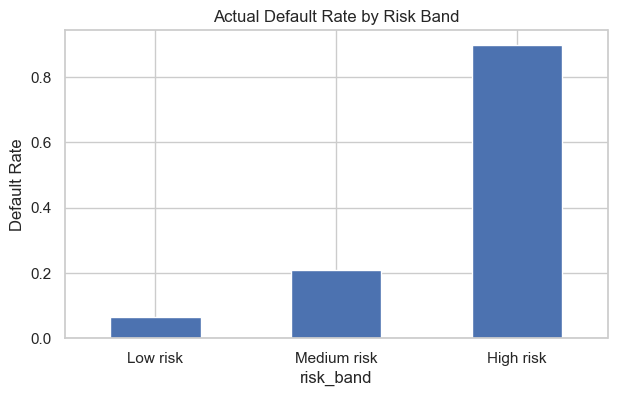

In [143]:
plt.figure(figsize=(7, 4))
band_summary["actual_default_rate"].plot(kind="bar")
plt.title("Actual Default Rate by Risk Band")
plt.ylabel("Default Rate")
plt.xticks(rotation=0)
plt.show()

## Segment Analysis

In [144]:
base_rate = y_test.mean()

In [145]:
segment_rows = []
for col in categorical_features:
    grouped = risk_df.groupby(col)["actual_default"].agg(["mean", "size"])
    for level, row in grouped.iterrows():
        if row["size"] < max(20, int(0.01 * len(risk_df))):
            continue
        segment_rows.append({
            "feature": col,
            "segment": str(level),
            "n": int(row["size"]),
            "default_rate": row["mean"],
            "lift_vs_base": row["mean"] / base_rate
        })

In [146]:
segment_df = pd.DataFrame(segment_rows).sort_values("lift_vs_base", ascending=False)

In [147]:
print("Base default rate:", round(base_rate, 4))

Base default rate: 0.2465


In [148]:
segment_df.head(15)

,feature,segment,n,default_rate,lift_vs_base
24,lump_sum_payment,lpsm,728,0.810440,3.288429
20,Neg_ammortization,neg_amm,2977,0.448438,1.819576
9,loan_type,type2,4200,0.346190,1.404698
18,business_or_commercial,b/c,4200,0.346190,1.404698
1,loan_limit,ncf,1978,0.334681,1.357999
12,loan_purpose,p2,629,0.330684,1.341778
16,Credit_Worthiness,l2,1282,0.322933,1.310329
33,co-applicant_credit_type,EXP,14961,0.309739,1.256792
39,age,>74,1430,0.304895,1.237139
27,occupancy_type,ir,1467,0.304022,1.233595


In [149]:
os.makedirs("artifacts", exist_ok=True)

In [150]:
joblib.dump(best_pipe, "artifacts/loan_default_model.joblib")

['artifacts/loan_default_model.joblib']

In [151]:
with open("artifacts/model_info.txt", "w") as f:
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Strategy: {best_strategy}\n")
    f.write(f"Threshold: {best_threshold:.4f}\n")
    for name, value in metrics.items():
        f.write(f"{name}: {value:.4f}\n")

In [152]:
cv_results.to_csv("artifacts/cv_results.csv", index=False)
importance_df.to_csv("artifacts/feature_importance.csv", index=False)

In [153]:
print("Artifacts saved in the 'artifacts' folder.")

Artifacts saved in the 'artifacts' folder.
